In [35]:
import sys
from pathlib import Path

# Get the current notebook's directory's parent directory
project_root = Path().resolve().parent.parent

# Add the project root (one level up) to sys.path
sys.path.append(str(project_root))

In [36]:
import scripts.config as CONF

In [37]:
# use lod env
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Calculate potential index for each wall

The index is combined out of the following factors:
* solid wall area : the estimated area that could be used for greenery for this wall in m². The higher it is, the lower the costs for setting up greenery per m² and the higher the benefit
* window-to-wall ratio (wwr_corrected): the lower the WWR is (fewer windows and doors), the lower the maintenance effort and costs
* orientation: the more south oriented the wall is, the higher the benefit for heat stress reduction

For this:
* the first three factors are scaled to be from 0 to 1, 1 being the best possible value
* an index is built by combining those scaled factors

In [38]:
# for paper reproducability, look at the dataframe with lod factors 
df2_walls = pd.read_pickle(CONF.dataframes_dir + "df2_walls_02_all_lod_factors_exmp.pkl")
df2_walls.head(5)

,building_id,wall_id,surface_coordinates,ground_surface,area,normal_vector_3d,wall_height,wall_width,angle_deg,orientation,outside_bounding_box,outside
37224,DENW38AL1000043V,ID_4bb7cc11-53ad-483b-9312-17bb9be0b548,"POLYGON Z ((358729.986 5655123.594 55.372, 358...","POLYGON Z ((358722.839 5655121.543 46.388, 358...",66.800260,"[18.426183999799196, -64.20864799997491, 0.0]",8.984,7.147,163.987921,S,"[(358722.83899999986, 5655121.543, 55.372), (3...",True
37325,DENW38AL10000BXL,ID_89539e11-04a5-443f-93ea-2aefcb18cf2d,"POLYGON Z ((358271.942 5655690.95 52.234, 3582...","POLYGON Z ((358262.684 5655700.935 44.878, 358...",11.956484,"[1.2489749979320919, -10.208289000201624, -0.0]",7.356,1.839,173.024581,S,"[(358271.942, 5655690.95, 52.234), (358273.781...",True
38000,DENW38AL100007ZJ,ID_7b36fa22-6491-4fd0-bda0-fbf080445419,"POLYGON Z ((358799.763 5655143.405 59.062, 358...","POLYGON Z ((358796.437 5655155.967 46.422, 358...",164.254901,"[-158.7836799989641, -42.04064000001178, 0.0]",12.640,3.326,104.829739,W,"[(358796.4370000002, 5655155.967, 59.062), (35...",True
51422,DENW38AL10000C3E,ID_8a5e2ae9-ebff-4ca5-8351-d94737df4e11,"POLYGON Z ((359688.242 5655192.401 51.643, 359...","POLYGON Z ((359680.143 5655159.758 45.119, 359...",87.142011,"[-84.52566400470775, 20.91645399968758, 0.0]",6.524,3.211,76.100979,W,"[(359691.4529999999, 5655205.377, 51.643), (35...",True


In [39]:
df5_streetview_fused_avg = pd.read_pickle(CONF.dataframes_dir + "df5_streetview_fused_averaged_per_wall.pkl")
df5_streetview_fused_avg.head(5)

,wall_id,building_id,average_wwr,average_swa,fusion_source
0,ID_4bb7cc11-53ad-483b-9312-17bb9be0b548,DENW38AL1000043V,0.232467,51.271426,both
1,ID_7b36fa22-6491-4fd0-bda0-fbf080445419,DENW38AL100007ZJ,0.135733,141.960036,both
2,ID_89539e11-04a5-443f-93ea-2aefcb18cf2d,DENW38AL10000BXL,0.000000,11.956484,both
3,ID_8a5e2ae9-ebff-4ca5-8351-d94737df4e11,DENW38AL10000C3E,0.130600,75.761264,both


In [40]:
df5_oblique_fused_avg = pd.read_pickle(CONF.dataframes_dir + "df5_oblique_fused_averaged_per_wall.pkl")
df5_oblique_fused_avg.head(5)

,wall_id,building_id,average_wwr,average_swa,fusion_source
0,ID_4bb7cc11-53ad-483b-9312-17bb9be0b548,DENW38AL1000043V,0.2420,50.634597,both
1,ID_7b36fa22-6491-4fd0-bda0-fbf080445419,DENW38AL100007ZJ,0.1292,143.033168,both
2,ID_89539e11-04a5-443f-93ea-2aefcb18cf2d,DENW38AL10000BXL,0.0000,11.956484,both
3,ID_8a5e2ae9-ebff-4ca5-8351-d94737df4e11,DENW38AL10000C3E,0.1335,75.508552,both


In [41]:
df5_averages = pd.merge(
    df5_oblique_fused_avg,
    df5_streetview_fused_avg,
    how="outer",
    on=["wall_id", "building_id"],
    suffixes=("_oblique", "_streetview")
)#.dropna()
df5_averages['average_wwr_combined'] = df5_averages[['average_wwr_streetview', 'average_wwr_oblique']].mean(axis=1)
df5_averages['average_swa_combined'] = df5_averages[['average_swa_streetview', 'average_swa_oblique']].mean(axis=1)

df5_averages = pd.merge(
    df5_averages,
    df2_walls[['wall_id', 'orientation', 'angle_deg', 'area']], 
    on="wall_id")

df5_averages

,wall_id,building_id,average_wwr_oblique,average_swa_oblique,fusion_source_oblique,average_wwr_streetview,average_swa_streetview,fusion_source_streetview,average_wwr_combined,average_swa_combined,orientation,angle_deg,area
0,ID_4bb7cc11-53ad-483b-9312-17bb9be0b548,DENW38AL1000043V,0.2420,50.634597,both,0.232467,51.271426,both,0.237233,50.953012,S,163.987921,66.800260
1,ID_7b36fa22-6491-4fd0-bda0-fbf080445419,DENW38AL100007ZJ,0.1292,143.033168,both,0.135733,141.960036,both,0.132467,142.496602,W,104.829739,164.254901
2,ID_89539e11-04a5-443f-93ea-2aefcb18cf2d,DENW38AL10000BXL,0.0000,11.956484,both,0.000000,11.956484,both,0.000000,11.956484,S,173.024581,11.956484
3,ID_8a5e2ae9-ebff-4ca5-8351-d94737df4e11,DENW38AL10000C3E,0.1335,75.508552,both,0.130600,75.761264,both,0.132050,75.634908,W,76.100979,87.142011


In [42]:
# define where to find values for index
wwr_column = "average_wwr_combined"
swa_column = "average_swa_combined"
orientation_column = "angle_deg" # angle to north in degrees

In [43]:
print("mean wwr: ", df5_averages[wwr_column].mean())
print("mean swa: ", df5_averages[swa_column].mean())

mean wwr:  0.1254375
mean swa:  70.26025148586797


## Scale main factors 

In [44]:
def plot_hist(data, bins = 50, title = "Histogram", x = "Factor", y = "Number of walls", save_path = None, ylog = False):
    ''' 
    Plots and displays a histogram using the provided data, with an option to save the figure.

    PARAMS:
    * data: A 1D array-like structure containing the data to be plotted in the histogram.
    * bins: (Optional) An integer specifying the number of bins to use for the histogram (default is 50).
    * title: (Optional) A string representing the title of the histogram (default is "Histogram").
    * x: (Optional) A string representing the label for the x-axis (default is "Factor").
    * y: (Optional) A string representing the label for the y-axis (default is "Number of walls").
    * save_path: (Optional) A string representing the file path where the histogram image will be saved. If None, the histogram will not be saved.
    * ylog: (Optional) A boolean indicating whether to use a logarithmic scale for the y-axis (default is False).
    '''
    # make hist
    plt.hist(data, bins = bins, alpha=0.9, edgecolor='black')

    # add title and axis labels
    # set text sizes quite high so that they are still readable if plots are shown rather small in thesis
    #plt.title(title, fontsize = 17)
    plt.xlabel(x, fontsize = 15)
    plt.ylabel(y, fontsize = 15)
    plt.yticks(fontsize = 13)
    plt.xticks(fontsize = 13)

    # x axis should always start with 0
    plt.xlim(0)

    # make y a log scale if wanted
    if ylog:
        plt.yscale('log')

    plt.tight_layout()

    # save figure if wanted
    if save_path is not None:
        plt.savefig(save_path)#, transparent = True)
        
    plt.show()

### Solid wall area

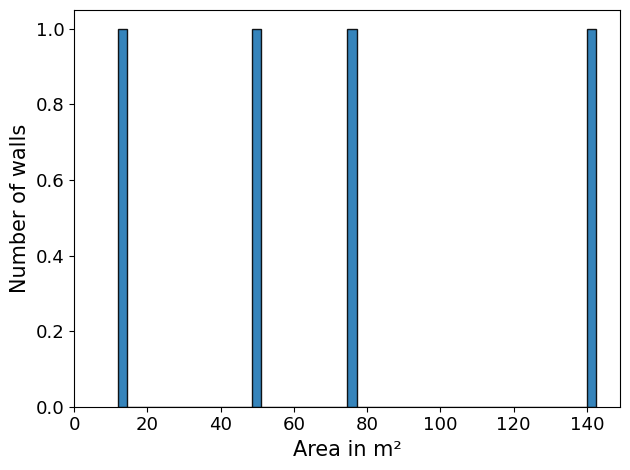

In [45]:
# look at factor
plot_hist(df5_averages[swa_column], x = "Area in m²", title = "Solid Wall Area", save_path="swa_orig.png")

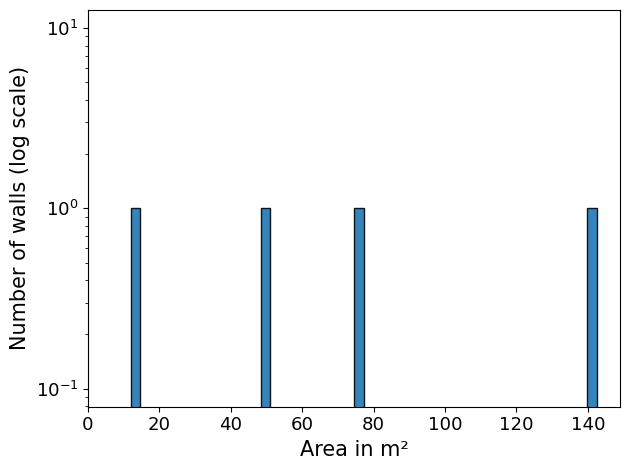

In [46]:
# look at factor - log
plot_hist(df5_averages[swa_column], x = "Area in m²", y = "Number of walls (log scale)", title = "Solid Wall Area", save_path="swa_orig_log.png", ylog=True)

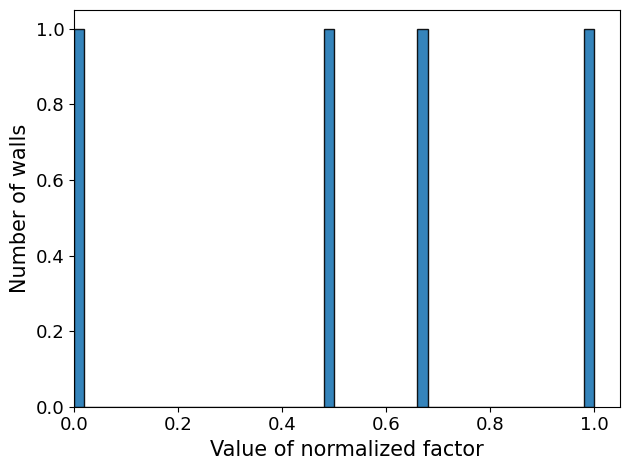

In [47]:
# the extremes can not stay so extreme, but a log conversion would reduce the values that stand for really good walls for vertical greenery too much, a power transformation with exponent of 0.3 was chosen, followed by a min-max normalisation
solid_wall_area_factor = df5_averages[swa_column]**0.3
solid_wall_area_factor = (solid_wall_area_factor - min(solid_wall_area_factor)) / (max(solid_wall_area_factor) - min(solid_wall_area_factor))
plot_hist(solid_wall_area_factor, x = "Value of normalized factor", title = "Solid Wall Area", save_path="swa_norm.png")

### wwr_corrected

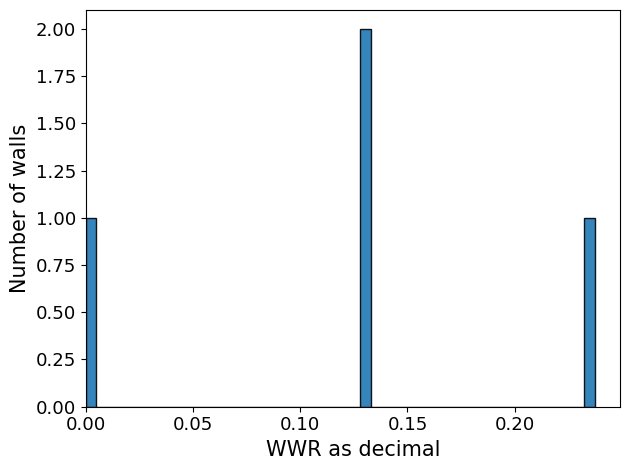

In [48]:
# look at factor
plot_hist(df5_averages[wwr_column], x = "WWR as decimal", title = "Window-to-wall ratio", save_path="wwr_orig.png")

In [49]:
# look at factor
#plot_hist(res_df[wwr_column], x = "WWR as decimal", y = "Number of walls (log scale)", title = "Window-to-wall ratio", save_path=figures_dir + "/wwr_orig_log.png", ylog=True)

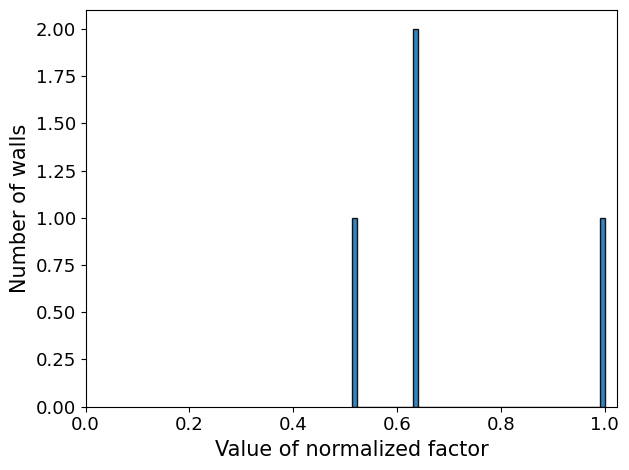

In [50]:
# take squareroot in order to span the range of most WWRs over a bigger range (-> counts more towards end index)
wwr_factor = df5_averages[wwr_column]**0.5
# the factor needs to be reversed as a low wwr means a high score
wwr_factor = 1-wwr_factor
plot_hist(wwr_factor, x = "Value of normalized factor", title = "Window-to-wall ratio", save_path="wwr_norm.png")

### orientation

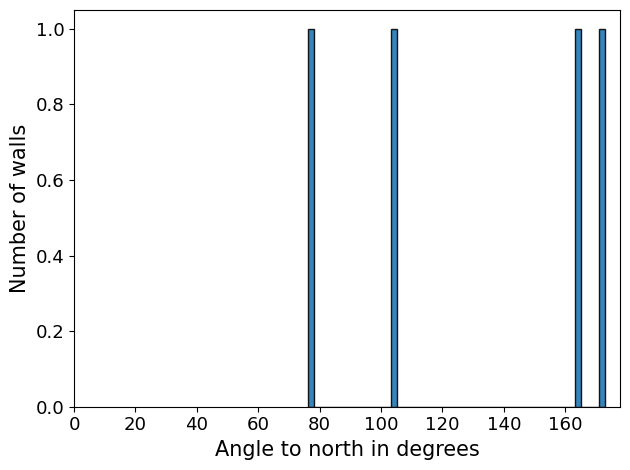

In [51]:
# look at factor
plot_hist(df5_averages[orientation_column], x = "Angle to north in degrees", title = "Orientation", save_path="orientation_orig.png")

In [52]:
# Conditions
conditions = [
    (df5_averages[orientation_column].between(0, 45)) | (df5_averages[orientation_column].between(315, 360)),  # North
    df5_averages[orientation_column].between(45, 135),   # West
    df5_averages[orientation_column].between(135, 225),  # South
    df5_averages[orientation_column].between(225, 315)  # East
]

# Corresponding factors
factors = [0.15, 0.35, 0.35, 0.5]

orientation_factor = np.select(conditions, factors, default=np.nan)
#orientation_factor

## Combine into index
Index from multiplication

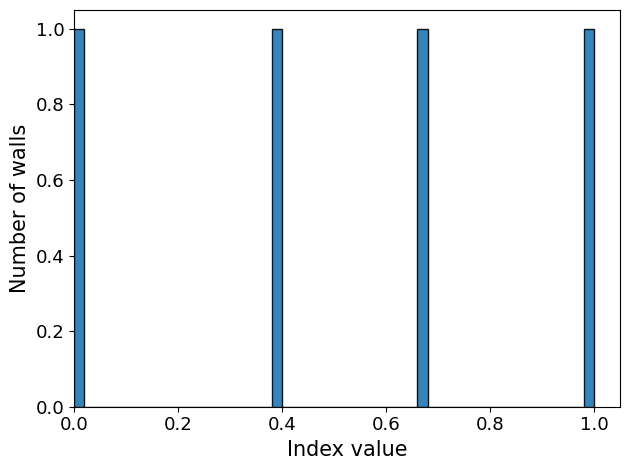

In [53]:
# index is built by multiplying  SSA and WWR and adding factor for orientation
index = (solid_wall_area_factor * wwr_factor) + orientation_factor
index = (index - min(index)) / (max(index) - min(index))

plot_hist(index, x = "Index value", title = "Index", save_path="index.png")

#### index with weighted sum (used in paper)

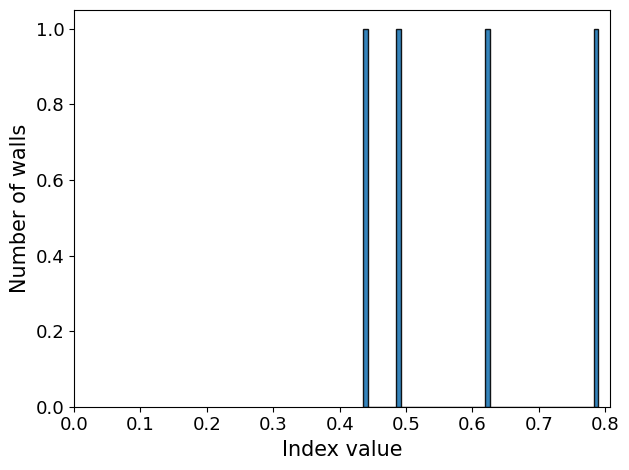

In [54]:
            # swa, wwr, orientation
w = np.array([0.50, 0.40, 0.1])
F = np.vstack([solid_wall_area_factor, wwr_factor, orientation_factor ]).T  # shape (N, K)

index_ws = F @ w
plot_hist(index_ws, x = "Index value", title = "Index", save_path= "index_weighted.png")

-----------

In [55]:
# add a rank to have something like a priority list, 1 is the wall with the highest potential
index_rank = (pd.Series(index_ws)).rank(ascending = False)
index_rank

0    3.0
1    1.0
2    4.0
3    2.0
dtype: float64

In [56]:
# include into df and save
df5_averages["potential_index"] = index
df5_averages["potential_rank"] = [int(rank) for rank in index_rank]
df5_averages.to_csv(CONF.dataframes_dir + "/df_factors_and_potential_index_ws.csv", index = False)

### EXAMPLE
This is example data to see how the output would look like

In [57]:
top_ten = df5_averages[df5_averages["potential_rank"] <=10].sort_values("potential_rank")
top_ten

,wall_id,building_id,average_wwr_oblique,average_swa_oblique,fusion_source_oblique,average_wwr_streetview,average_swa_streetview,fusion_source_streetview,average_wwr_combined,average_swa_combined,orientation,angle_deg,area,potential_index,potential_rank
1,ID_7b36fa22-6491-4fd0-bda0-fbf080445419,DENW38AL100007ZJ,0.1292,143.033168,both,0.135733,141.960036,both,0.132467,142.496602,W,104.829739,164.254901,1.000000,1
3,ID_8a5e2ae9-ebff-4ca5-8351-d94737df4e11,DENW38AL10000C3E,0.1335,75.508552,both,0.130600,75.761264,both,0.132050,75.634908,W,76.100979,87.142011,0.670663,2
0,ID_4bb7cc11-53ad-483b-9312-17bb9be0b548,DENW38AL1000043V,0.2420,50.634597,both,0.232467,51.271426,both,0.237233,50.953012,S,163.987921,66.800260,0.398283,3
2,ID_89539e11-04a5-443f-93ea-2aefcb18cf2d,DENW38AL10000BXL,0.0000,11.956484,both,0.000000,11.956484,both,0.000000,11.956484,S,173.024581,11.956484,0.000000,4
